<a href="https://colab.research.google.com/github/kietietv/Report_XuLyData/blob/main/XuLyData_dulieuxettuyendaihoc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dữ liệu
df = pd.read_csv('/content/dulieuxettuyendaihoc.csv')
display(df.head())

,STT,T1,L1,H1,S1,V1,X1,D1,N1,T2,...,X6,D6,N6,GT,DT,KV,DH1,DH2,DH3,KT
0,1,7.2,7.3,6.3,7.3,7.0,7.9,7.3,5.5,8.4,...,6.6,7.6,5.9,F,NaN,2NT,3.25,3.25,4.50,A1
1,2,5.4,3.9,3.9,4.0,5.4,5.4,5.3,2.8,6.3,...,6.6,6.1,4.4,M,NaN,1,6.00,4.00,3.50,C
2,3,5.6,6.8,7.2,7.5,4.3,7.4,5.8,3.2,5.0,...,7.9,8.1,4.6,M,NaN,1,5.00,6.75,4.00,C
3,4,6.6,6.4,5.3,6.9,5.4,7.3,6.4,5.8,5.1,...,7.1,7.3,7.4,M,NaN,1,4.25,4.25,5.25,D1
4,5,6.0,5.0,6.0,7.3,6.5,7.7,7.9,6.1,5.4,...,6.1,7.5,7.2,M,NaN,2NT,4.25,4.50,5.00,A


### 1 & 2. Kiểm tra và xử lý giá trị thiếu

In [ ]:
# Kiểm tra thông tin thiếu
print("Số lượng giá trị thiếu mỗi cột:")
print(df.isnull().sum())

# Xử lý giá trị thiếu: Điền giá trị cho cột DT thay vì xóa toàn bộ dòng
df_cleaned = df.copy()
df_cleaned['DT'] = df_cleaned['DT'].fillna(0)

# Chỉ xóa những dòng vẫn còn giá trị null ở các cột quan trọng khác
df_cleaned = df_cleaned.dropna()
print(f"\nKích thước tập dữ liệu sau khi xử lý giá trị thiếu: {df_cleaned.shape}")

Số lượng giá trị thiếu mỗi cột:
STT     0
T1      0
L1      0
H1      0
S1      0
V1      0
X1      0
D1      0
N1      0
T2      0
L2      0
H2      0
S2      0
V2      0
X2      0
D2      0
N2      0
T3      0
L3      0
H3      0
S3      0
V3      0
X3      0
D3      0
N3      0
T4      0
L4      0
H4      0
S4      0
V4      0
X4      0
D4      0
N4      0
T5      0
L5      0
H5      0
S5      0
V5      0
X5      0
D5      0
N5      0
T6      0
L6      0
H6      0
S6      0
V6      0
X6      0
D6      0
N6      0
GT      0
DT     97
KV      0
DH1     0
DH2     0
DH3     0
KT      0
dtype: int64

Kích thước tập dữ liệu sau khi xử lý giá trị thiếu: (100, 56)


### 3. Phát hiện và xử lý Outliers (Dựa trên cột số thực)

In [ ]:
# Chọn các cột số để kiểm tra Outliers
num_cols = df_cleaned.select_dtypes(include=[np.number]).columns

def remove_outliers(df, columns):
    df_res = df.copy()
    for col in columns:
        Q1 = df_res[col].quantile(0.25)
        Q3 = df_res[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_res = df_res[(df_res[col] >= lower_bound) & (df_res[col] <= upper_bound)]
    return df_res

df_no_outliers = remove_outliers(df_cleaned, num_cols)
print(f"Kích thước dữ liệu sau khi loại bỏ Outliers: {df_no_outliers.shape}")

Kích thước dữ liệu sau khi loại bỏ Outliers: (67, 56)


### 4. Kiểm tra độ cân bằng dữ liệu (Class Balance)

Tỷ lệ phần trăm các lớp trong cột KT:
KT
A     56.716418
D1    20.895522
B     10.447761
A1     5.970149
C      5.970149
Name: proportion, dtype: float64


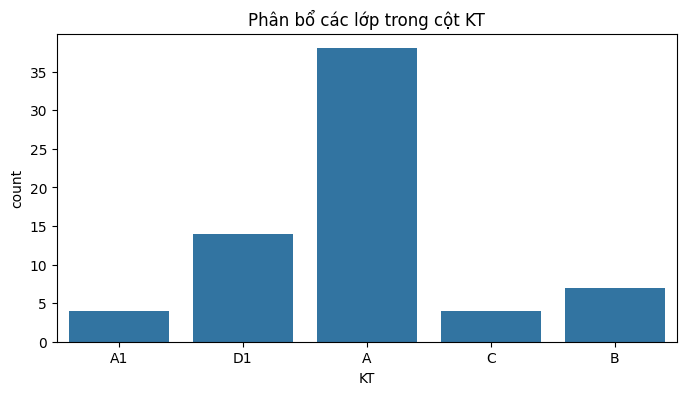

In [ ]:
# Kiểm tra độ cân bằng dữ liệu
# Sử dụng cột 'KT' làm ví dụ nếu 'KQ' chưa có trong dataset
target_column = 'KT'

if target_column in df_no_outliers.columns:
    balance_check = df_no_outliers[target_column].value_counts(normalize=True) * 100
    print(f"Tỷ lệ phần trăm các lớp trong cột {target_column}:")
    print(balance_check)

    plt.figure(figsize=(8, 4))
    sns.countplot(x=target_column, data=df_no_outliers)
    plt.title(f'Phân bổ các lớp trong cột {target_column}')
    plt.show()
else:
    print(f"Không tìm thấy cột {target_column} để kiểm tra độ cân bằng.")

### 5. Lưu dữ liệu đã làm sạch ra file CSV

In [ ]:
# Lưu DataFrame đã làm sạch vào một file CSV mới
output_path = '/content/dulieuxettuyendaihoc_cleaned.csv'
df_no_outliers.to_csv(output_path, index=False)

print(f"Dữ liệu đã được lưu thành công tại: {output_path}")

Dữ liệu đã được lưu thành công tại: /content/dulieuxettuyendaihoc_cleaned.csv
